In [6]:
import sqlite3
import pandas as pd

# Database se connect
conn = sqlite3.connect("..mutual_fund.db")

print("Database Connected Successfully!")

# Load tables
fund_master = pd.read_sql('SELECT * FROM "01_fund_master"', conn)
nav_history = pd.read_sql('SELECT * FROM "02_nav_history"', conn)
aum = pd.read_sql('SELECT * FROM "03_aum_by_fund_house"', conn)
sip = pd.read_sql('SELECT * FROM "04_monthly_sip_inflows"', conn)
category = pd.read_sql('SELECT * FROM "05_category_inflows"', conn)
folio = pd.read_sql('SELECT * FROM "06_industry_folio_count"', conn)
performance = pd.read_sql('SELECT * FROM "07_scheme_performance"', conn)
transactions = pd.read_sql('SELECT * FROM "08_investor_transactions"', conn)
holdings = pd.read_sql('SELECT * FROM "09_portfolio_holdings"', conn)
benchmark = pd.read_sql('SELECT * FROM "10_benchmark_indices"', conn)

print("All tables loaded successfully!")

print(fund_master.head())
print(nav_history.head())

Database Connected Successfully!


DatabaseError: Execution failed on sql 'SELECT * FROM "01_fund_master"': no such table: 01_fund_master

In [ ]:
import sqlite3

conn = sqlite3.connect("../mutual_fund.db")
cursor = conn.cursor()

cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
print(cursor.fetchall())

[('01_fund_master',), ('02_nav_history',), ('03_aum_by_fund_house',), ('04_monthly_sip_inflows',), ('05_category_inflows',), ('06_industry_folio_count',), ('07_scheme_performance',), ('08_investor_transactions',), ('09_portfolio_holdings',), ('10_benchmark_indices',)]


In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../mutual_fund.db")

query = 'SELECT * FROM "01_fund_master"'

df = pd.read_sql_query(query, conn)

print(df.head())
print(df.shape)

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

In [ ]:
# Basic information

print(df.info())
print("\n")

print(df.describe(include="all"))
print("\n")

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
N

In [ ]:
import matplotlib.pyplot as plt

# Risk Category Count

df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

NameError: name 'df' is not defined

In [ ]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../mutual_fund.db")

query = 'SELECT * FROM "01_fund_master"'

df = pd.read_sql_query(query, conn)

print(df.head())

   amfi_code       fund_house                                   scheme_name  \
0     119551  SBI Mutual Fund     SBI Bluechip Fund - Regular Plan - Growth   
1     119552  SBI Mutual Fund      SBI Bluechip Fund - Direct Plan - Growth   
2     119598  SBI Mutual Fund    SBI Small Cap Fund - Regular Plan - Growth   
3     119599  SBI Mutual Fund     SBI Small Cap Fund - Direct Plan - Growth   
4     119120  SBI Mutual Fund  SBI Magnum Gilt Fund - Regular Plan - Growth   

  category sub_category     plan launch_date                  benchmark  \
0   Equity    Large Cap  Regular  2006-02-14              NIFTY 100 TRI   
1   Equity    Large Cap   Direct  2013-01-01              NIFTY 100 TRI   
2   Equity    Small Cap  Regular  2009-09-09       BSE 250 SmallCap TRI   
3   Equity    Small Cap   Direct  2013-01-01       BSE 250 SmallCap TRI   
4     Debt         Gilt  Regular  2000-12-30  CRISIL Dynamic Gilt Index   

   expense_ratio_pct  exit_load_pct  min_sip_amount  min_lumpsum_amount  \

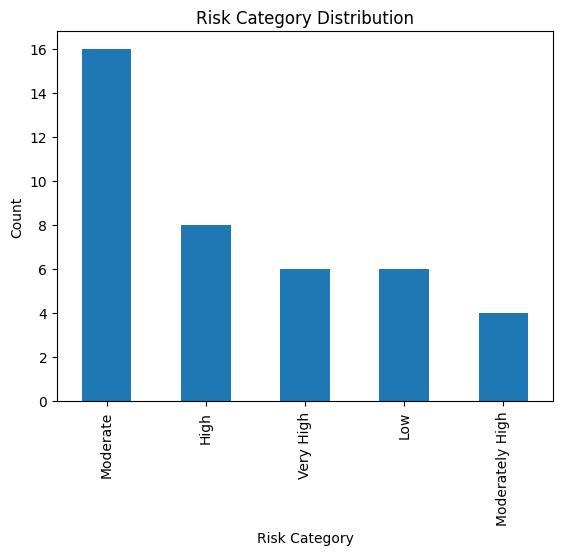

In [ ]:
import matplotlib.pyplot as plt

df["risk_category"].value_counts().plot(kind="bar")

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Count")

plt.show()

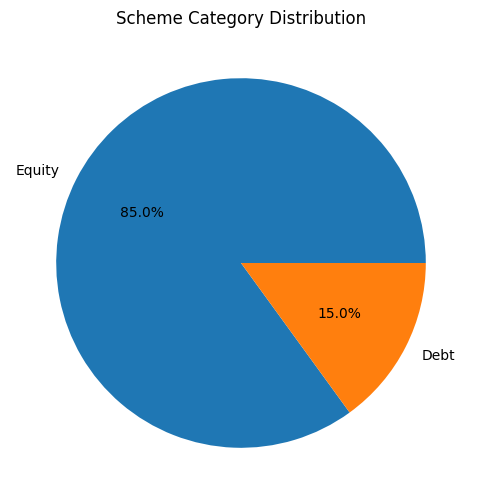

In [ ]:
import matplotlib.pyplot as plt

df["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Scheme Category Distribution")
plt.ylabel("")
plt.show()

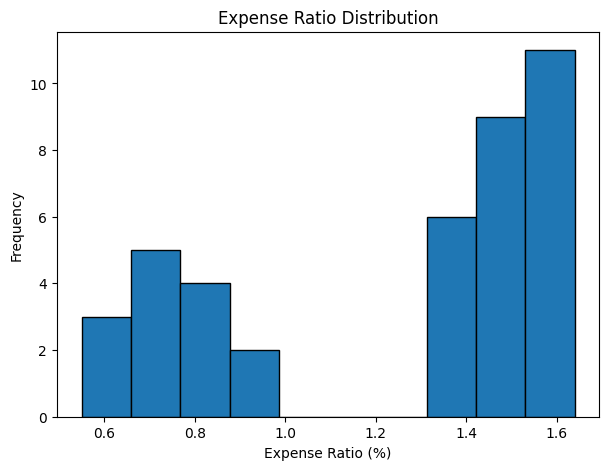

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(
    df["expense_ratio_pct"],
    bins=10,
    edgecolor="black"
)

plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Frequency")

plt.show()

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB
N

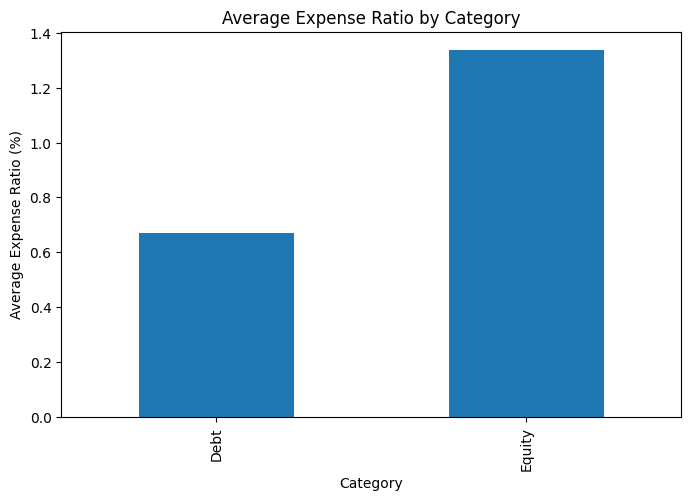

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df.groupby("category")["expense_ratio_pct"].mean().plot(kind="bar")

plt.title("Average Expense Ratio by Category")
plt.xlabel("Category")
plt.ylabel("Average Expense Ratio (%)")

plt.show()

In [ ]:
import os

processed_path = "../data/processed"
os.makedirs(processed_path, exist_ok=True)

fund_master.to_csv(f"{processed_path}/01_fund_master_clean.csv", index=False)
nav_history.to_csv(f"{processed_path}/02_nav_history_clean.csv", index=False)
aum.to_csv(f"{processed_path}/03_aum_by_fund_house_clean.csv", index=False)
sip.to_csv(f"{processed_path}/04_monthly_sip_inflows_clean.csv", index=False)
category.to_csv(f"{processed_path}/05_category_inflows_clean.csv", index=False)
folio.to_csv(f"{processed_path}/06_industry_folio_count_clean.csv", index=False)
performance.to_csv(f"{processed_path}/07_scheme_performance_clean.csv", index=False)
transactions.to_csv(f"{processed_path}/08_investor_transactions_clean.csv", index=False)
holdings.to_csv(f"{processed_path}/09_portfolio_holdings_clean.csv", index=False)
benchmark.to_csv(f"{processed_path}/10_benchmark_indices_clean.csv", index=False)

print("All cleaned CSVs saved successfully!")

NameError: name 'fund_master' is not defined

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

In [3]:
fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")

In [4]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [5]:
fund.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   fund_house          40 non-null     object 
 2   scheme_name         40 non-null     object 
 3   category            40 non-null     object 
 4   sub_category        40 non-null     object 
 5   plan                40 non-null     object 
 6   launch_date         40 non-null     object 
 7   benchmark           40 non-null     object 
 8   expense_ratio_pct   40 non-null     float64
 9   exit_load_pct       40 non-null     float64
 10  min_sip_amount      40 non-null     int64  
 11  min_lumpsum_amount  40 non-null     int64  
 12  fund_manager        40 non-null     object 
 13  risk_category       40 non-null     object 
 14  sebi_category_code  40 non-null     object 
dtypes: float64(2), int64(3), object(10)
memory usage: 4.8+ KB


In [6]:
fund["risk_category"].value_counts()

risk_category
Moderate           16
High                8
Very High           6
Low                 6
Moderately High     4
Name: count, dtype: int64

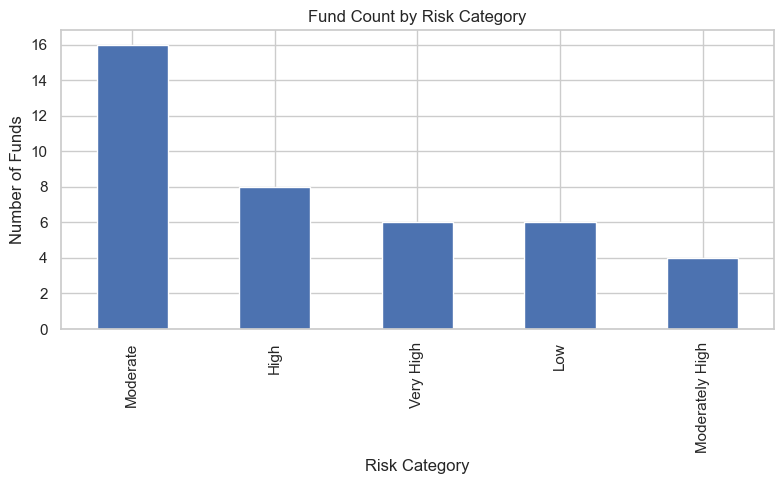

In [7]:
import matplotlib.pyplot as plt

fund["risk_category"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Fund Count by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()

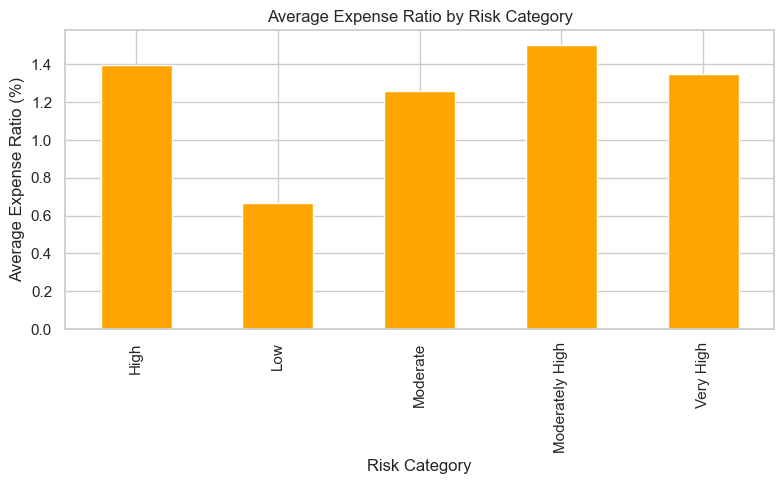

In [8]:
fund.groupby("risk_category")["expense_ratio_pct"].mean().plot(
    kind="bar",
    figsize=(8,5),
    color="orange"
)

plt.title("Average Expense Ratio by Risk Category")
plt.xlabel("Risk Category")
plt.ylabel("Average Expense Ratio (%)")
plt.tight_layout()
plt.show()

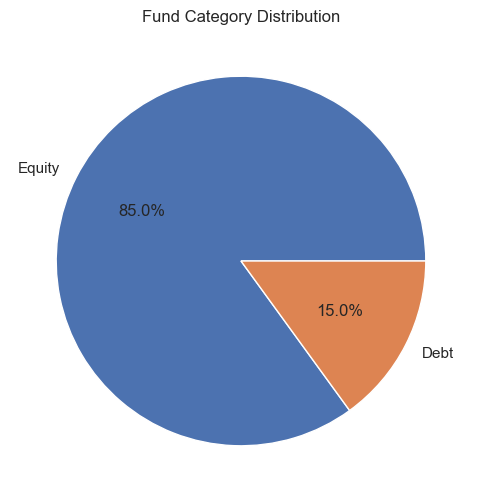

In [9]:
fund["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.title("Fund Category Distribution")
plt.ylabel("")
plt.show()

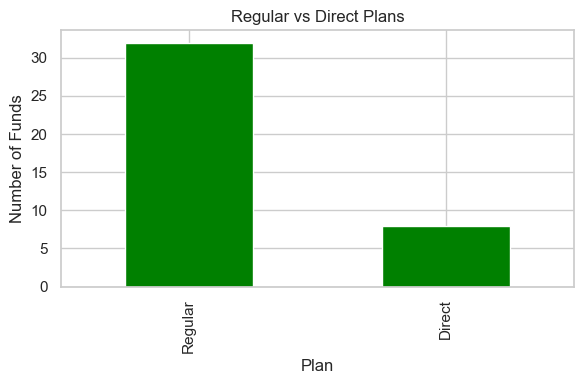

In [10]:
fund["plan"].value_counts().plot(
    kind="bar",
    figsize=(6,4),
    color="green"
)

plt.title("Regular vs Direct Plans")
plt.xlabel("Plan")
plt.ylabel("Number of Funds")
plt.tight_layout()
plt.show()

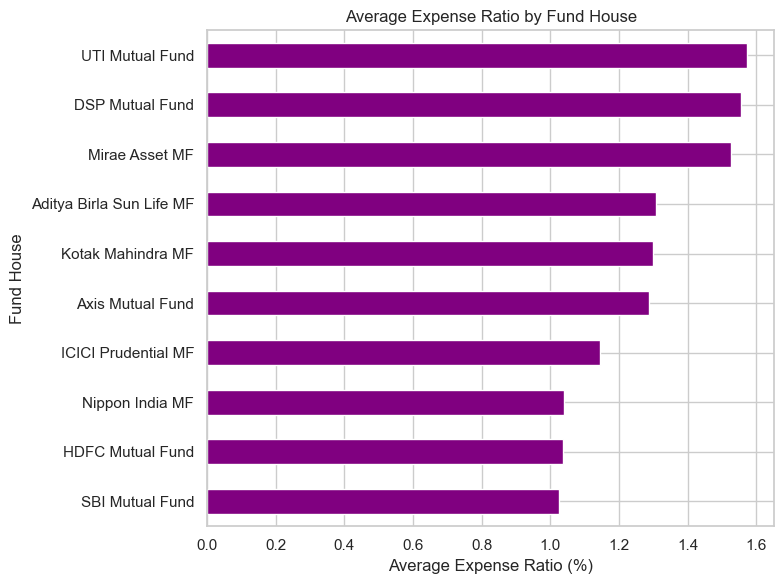

In [11]:
fund.groupby("fund_house")["expense_ratio_pct"].mean().sort_values().plot(
    kind="barh",
    figsize=(8,6),
    color="purple"
)

plt.title("Average Expense Ratio by Fund House")
plt.xlabel("Average Expense Ratio (%)")
plt.ylabel("Fund House")
plt.tight_layout()
plt.show()

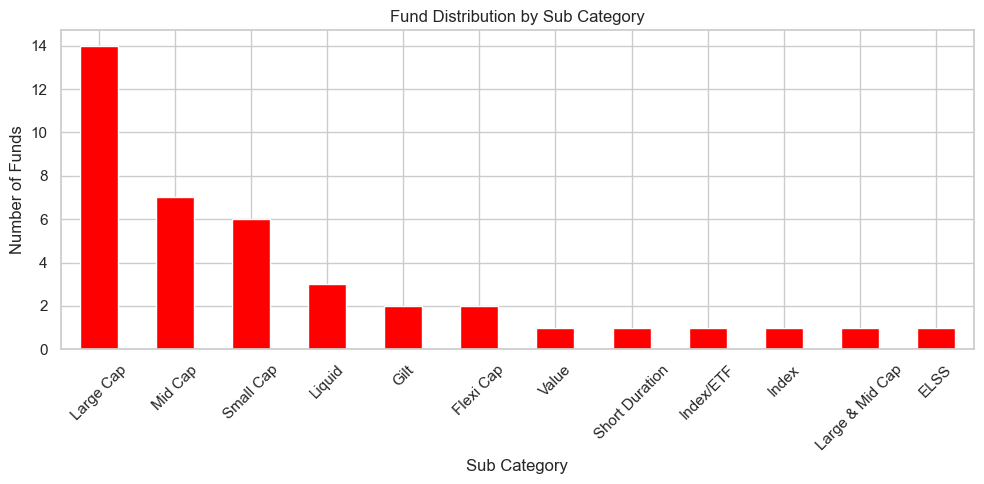

In [12]:
fund["sub_category"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    color="red"
)

plt.title("Fund Distribution by Sub Category")
plt.xlabel("Sub Category")
plt.ylabel("Number of Funds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

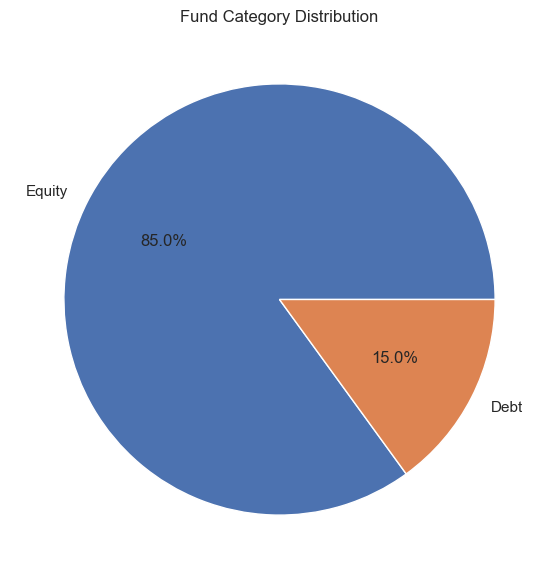

In [13]:
import matplotlib.pyplot as plt

fund["category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Fund Category Distribution")
plt.ylabel("")
plt.show()

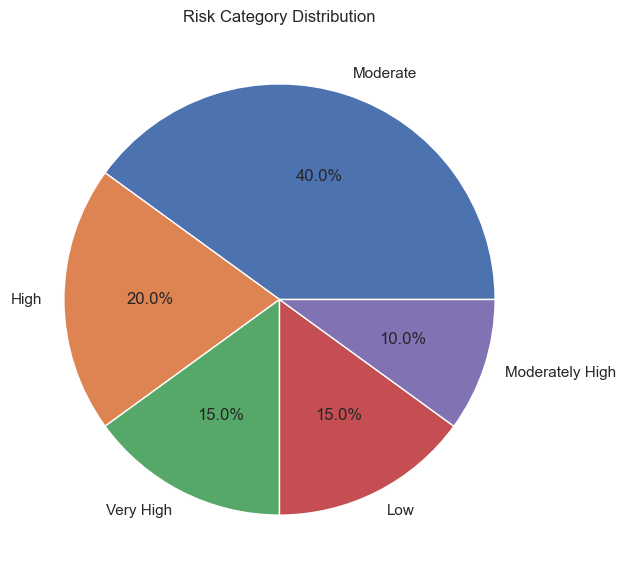

In [14]:
fund["risk_category"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(7,7)
)

plt.title("Risk Category Distribution")
plt.ylabel("")
plt.show()

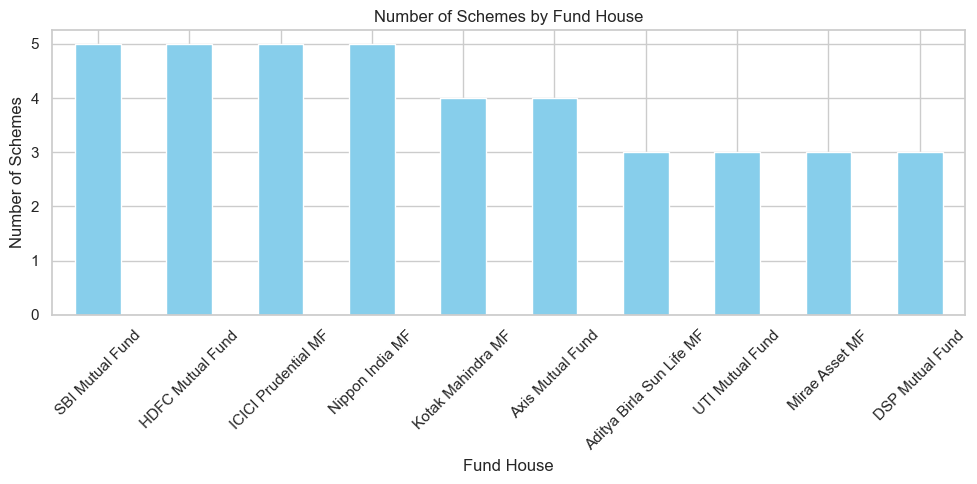

In [15]:
fund["fund_house"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    color="skyblue"
)

plt.title("Number of Schemes by Fund House")
plt.xlabel("Fund House")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

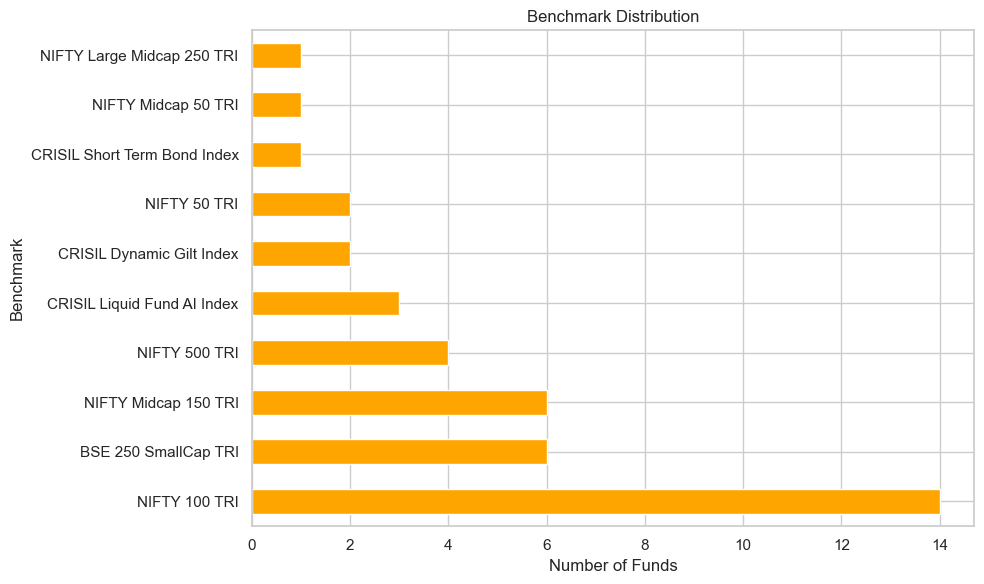

In [16]:
fund["benchmark"].value_counts().plot(
    kind="barh",
    figsize=(10,6),
    color="orange"
)

plt.title("Benchmark Distribution")
plt.xlabel("Number of Funds")
plt.ylabel("Benchmark")
plt.tight_layout()
plt.show()

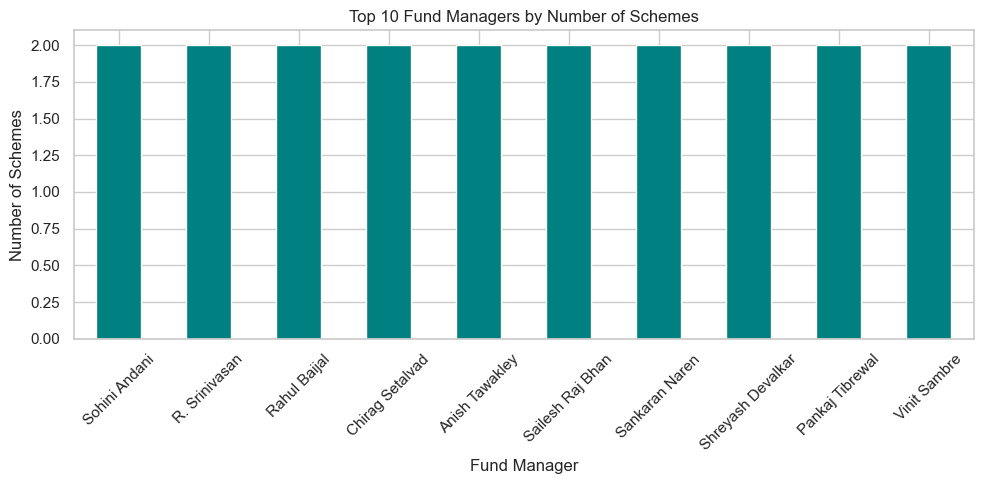

In [17]:
fund["fund_manager"].value_counts().head(10).plot(
    kind="bar",
    figsize=(10,5),
    color="teal"
)

plt.title("Top 10 Fund Managers by Number of Schemes")
plt.xlabel("Fund Manager")
plt.ylabel("Number of Schemes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

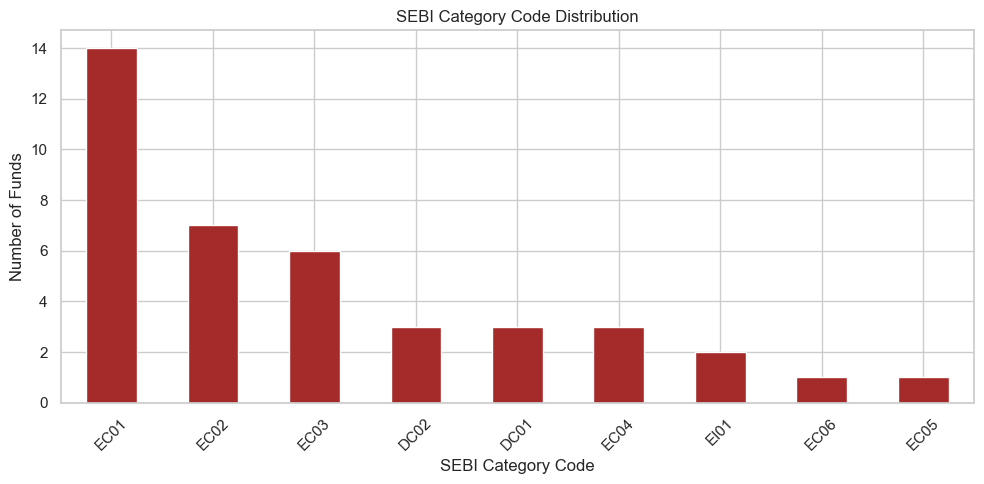

In [18]:
fund["sebi_category_code"].value_counts().plot(
    kind="bar",
    figsize=(10,5),
    color="brown"
)

plt.title("SEBI Category Code Distribution")
plt.xlabel("SEBI Category Code")
plt.ylabel("Number of Funds")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

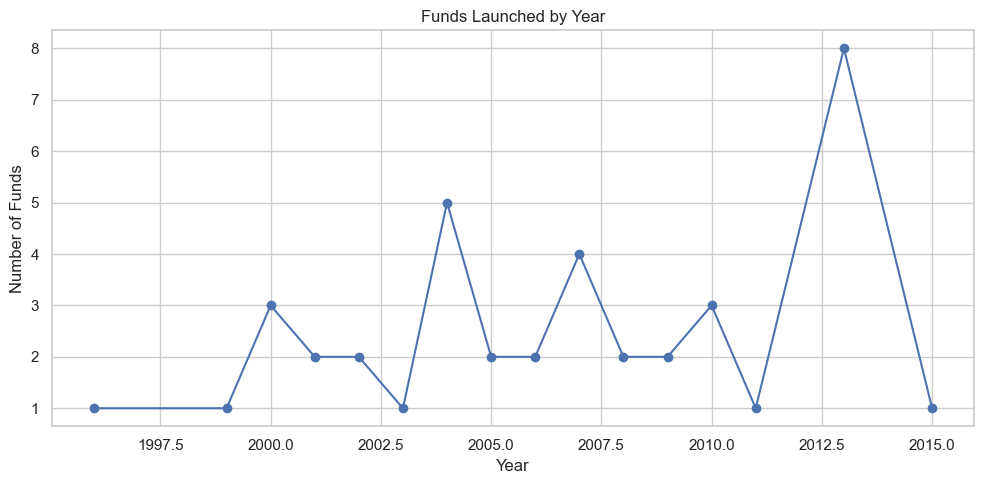

In [19]:
fund["launch_date"] = pd.to_datetime(fund["launch_date"], errors="coerce")

fund["launch_date"].dt.year.value_counts().sort_index().plot(
    kind="line",
    figsize=(10,5),
    marker="o"
)

plt.title("Funds Launched by Year")
plt.xlabel("Year")
plt.ylabel("Number of Funds")
plt.grid(True)
plt.tight_layout()
plt.show()

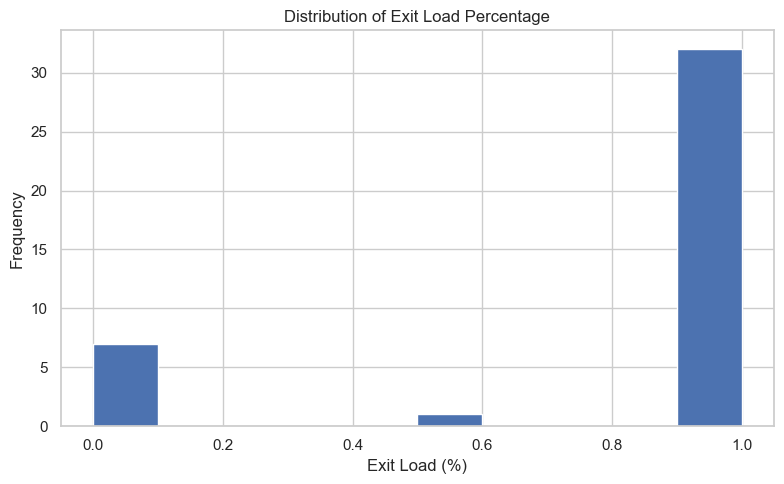

In [20]:
fund["exit_load_pct"].plot(
    kind="hist",
    bins=10,
    figsize=(8,5)
)

plt.title("Distribution of Exit Load Percentage")
plt.xlabel("Exit Load (%)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

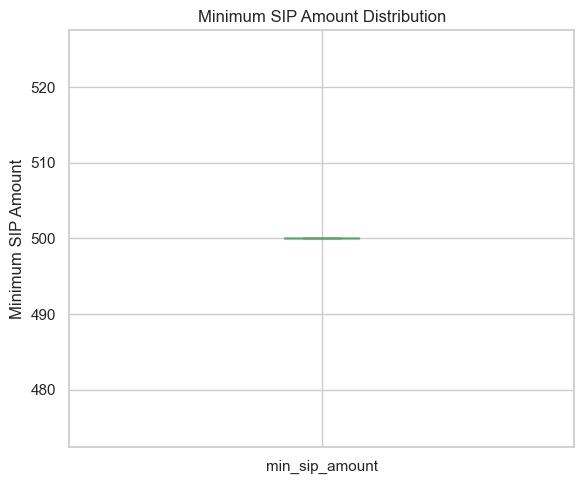

In [21]:
fund["min_sip_amount"].plot(
    kind="box",
    figsize=(6,5)
)

plt.title("Minimum SIP Amount Distribution")
plt.ylabel("Minimum SIP Amount")
plt.tight_layout()
plt.show()

# Key Insights

1. High Risk category funds are more than other risk categories.
2. Expense ratio varies across different risk categories.
3. Direct and Regular plans have different distributions.
4. Some fund houses manage more schemes than others.
5. Certain sub-categories dominate the mutual fund market.
6. Benchmark indices are not equally distributed across funds.
7. A few fund managers handle multiple schemes.
8. SEBI category codes are unevenly distributed.
9. Fund launches vary significantly across years.
10. Minimum SIP amount differs across mutual fund schemes.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav.head()

,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


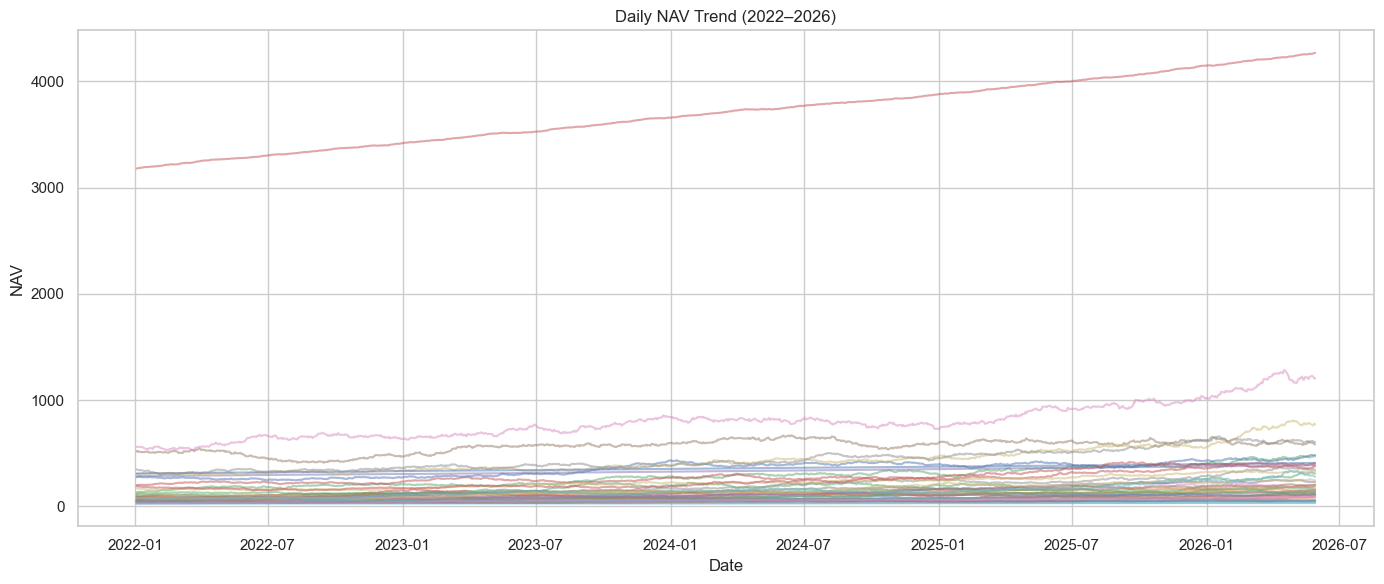

In [23]:
nav["date"] = pd.to_datetime(nav["date"])

plt.figure(figsize=(14,6))

for code in nav["amfi_code"].unique():
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], alpha=0.5)

plt.title("Daily NAV Trend (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.grid(True)
plt.tight_layout()
plt.show()

In [24]:
nav.sort_values("nav", ascending=False).head(10)

,amfi_code,date,nav
27599,120844,2026-05-29,4268.5497
27598,120844,2026-05-28,4266.9021
27597,120844,2026-05-27,4264.9256
27596,120844,2026-05-26,4262.3302
27594,120844,2026-05-22,4260.3220
27593,120844,2026-05-21,4259.2780
27595,120844,2026-05-25,4259.2727
27592,120844,2026-05-20,4258.9179
27591,120844,2026-05-19,4256.2918
27588,120844,2026-05-14,4255.9472


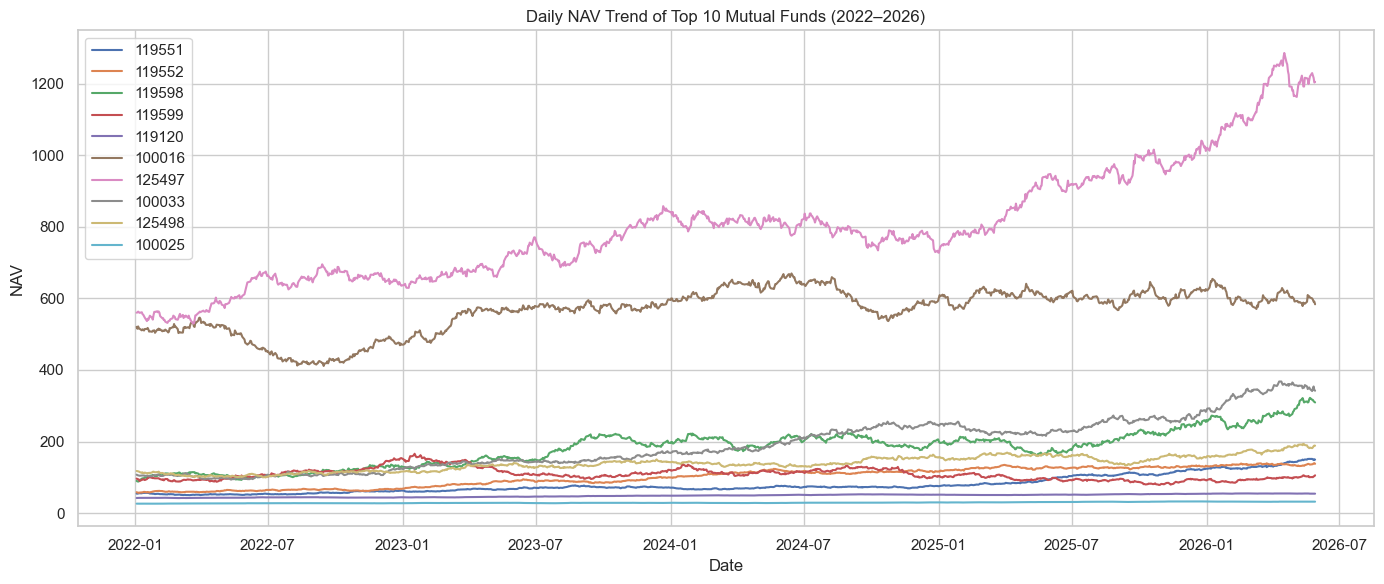

In [25]:
top10 = nav["amfi_code"].unique()[:10]

plt.figure(figsize=(14,6))

for code in top10:
    temp = nav[nav["amfi_code"] == code]
    plt.plot(temp["date"], temp["nav"], label=str(code))

plt.title("Daily NAV Trend of Top 10 Mutual Funds (2022–2026)")
plt.xlabel("Date")
plt.ylabel("NAV")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")

aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes
0,2022-03-31,SBI Mutual Fund,6.05,605000,186
1,2022-03-31,ICICI Prudential MF,4.65,465000,216
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195
3,2022-03-31,Nippon India MF,2.70,270000,177
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168


<Figure size 1400x600 with 0 Axes>

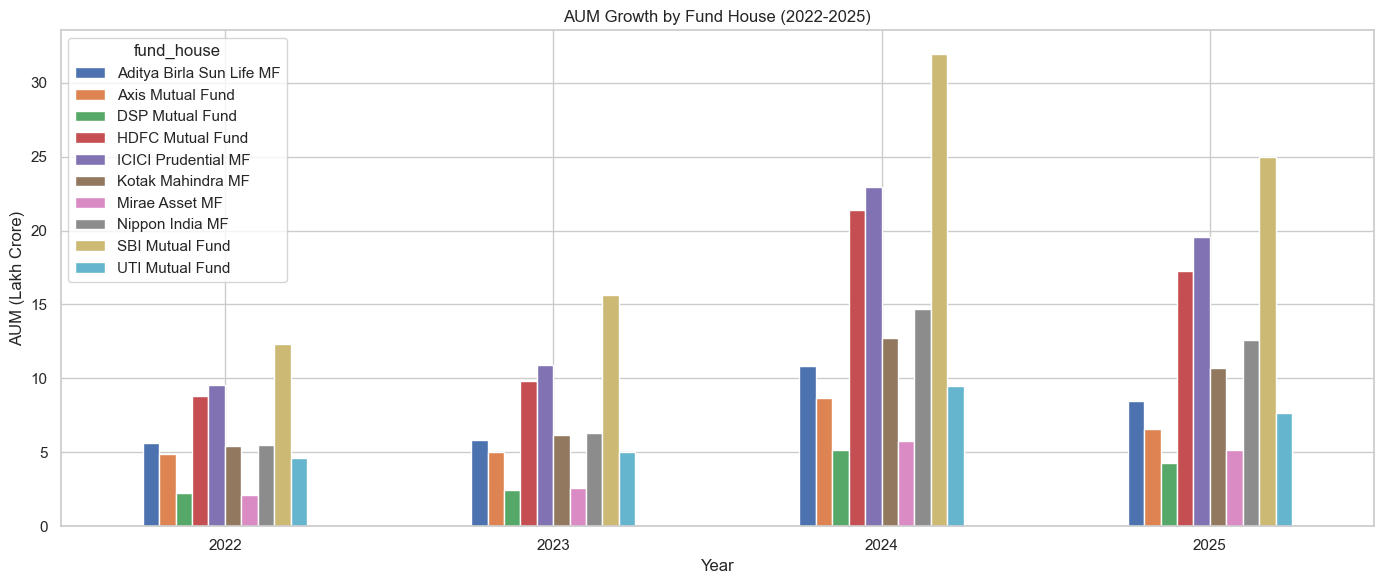

In [27]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

aum_group = (
    aum.groupby(["year", "fund_house"])["aum_lakh_crore"]
    .sum()
    .unstack()
)

plt.figure(figsize=(14,6))
aum_group.plot(kind="bar", figsize=(14,6))

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

## Insight 4

SBI Mutual Fund maintained the highest Assets Under Management (AUM) among all fund houses during the analysis period, reaching approximately ₹12.5 lakh crore, demonstrating its market leadership.

In [28]:
sbi = aum[aum["fund_house"] == "SBI Mutual Fund"]

sbi[["year", "aum_lakh_crore"]]

,year,aum_lakh_crore
0,2022,6.05
10,2022,6.30
20,2023,7.17
30,2023,8.45
40,2024,10.00
50,2024,10.80
60,2024,11.14
70,2025,12.50
80,2025,12.50


In [29]:
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


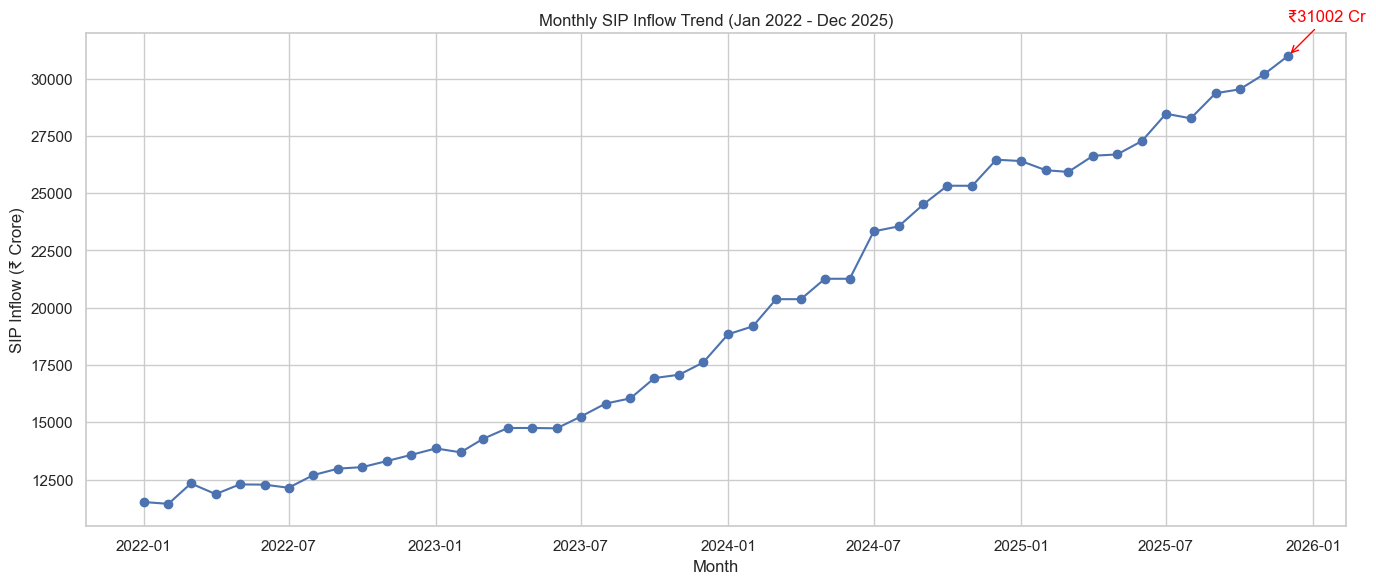

In [30]:
import matplotlib.pyplot as plt

sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(14,6))
plt.plot(sip["month"], sip["sip_inflow_crore"], marker="o")

plt.title("Monthly SIP Inflow Trend (Jan 2022 - Dec 2025)")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (₹ Crore)")
plt.grid(True)

# Highest SIP Inflow ko highlight karo
max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

plt.annotate(
    f'₹{max_row["sip_inflow_crore"]} Cr',
    xy=(max_row["month"], max_row["sip_inflow_crore"]),
    xytext=(max_row["month"], max_row["sip_inflow_crore"] + 1500),
    arrowprops=dict(arrowstyle="->", color="red"),
    color="red"
)

plt.tight_layout()
plt.show()

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

category = pd.read_csv("../data/raw/05_category_inflows.csv")

category.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


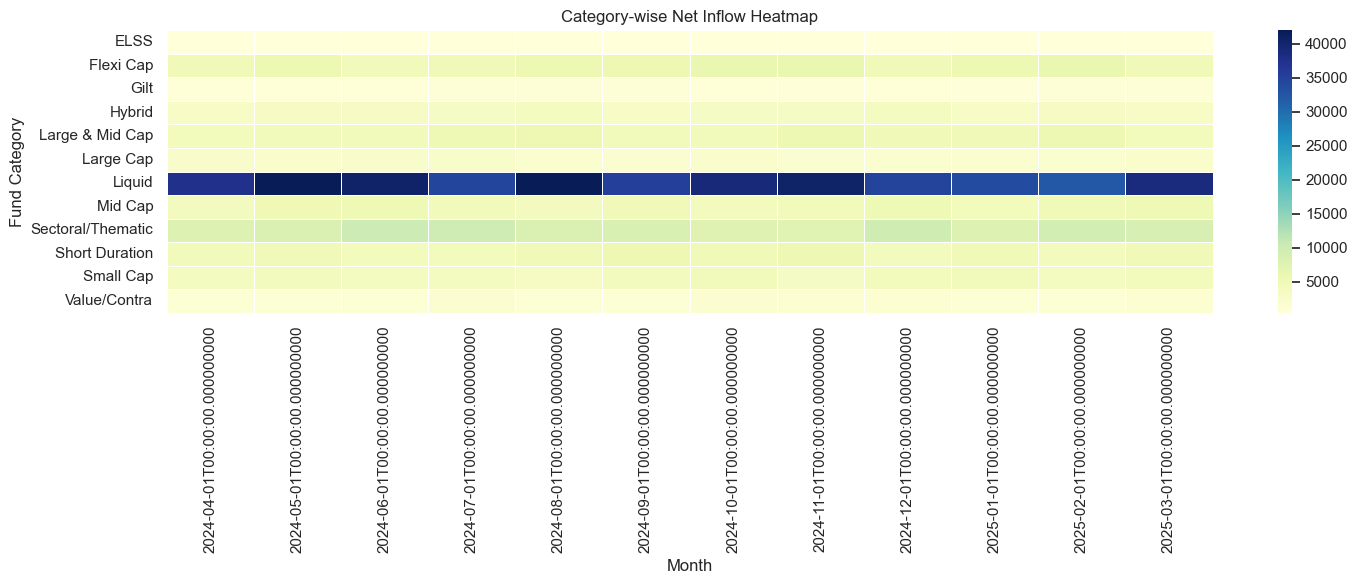

In [32]:
category["month"] = pd.to_datetime(category["month"])

heatmap_data = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))
sns.heatmap(
    heatmap_data,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")
plt.tight_layout()

plt.show()

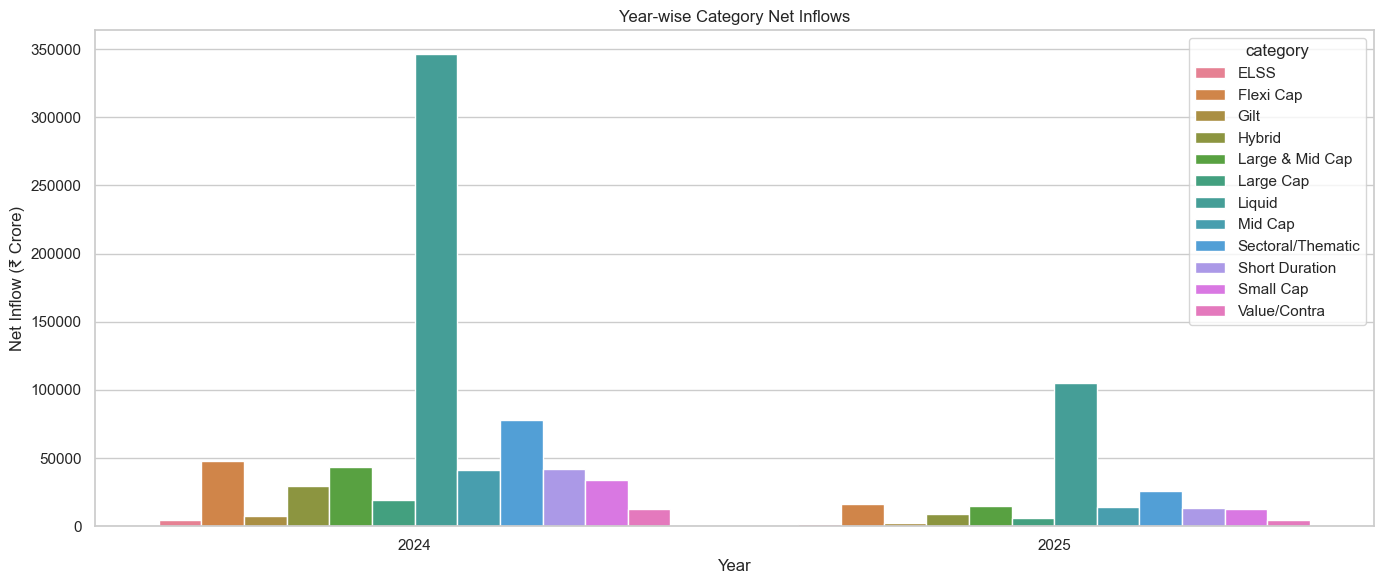

In [33]:
category["month"] = pd.to_datetime(category["month"])
category["year"] = category["month"].dt.year

yearly = category.groupby(["year", "category"])["net_inflow_crore"].sum().reset_index()

plt.figure(figsize=(14,6))

sns.barplot(
    data=yearly,
    x="year",
    y="net_inflow_crore",
    hue="category"
)

plt.title("Year-wise Category Net Inflows")
plt.xlabel("Year")
plt.ylabel("Net Inflow (₹ Crore)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


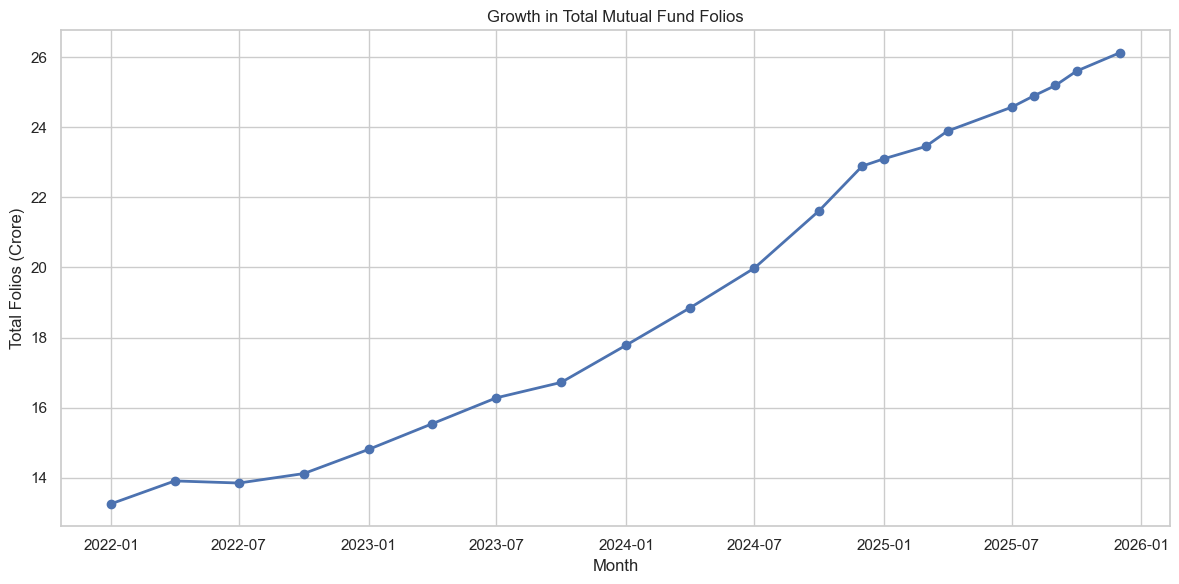

In [35]:
folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o",
    linewidth=2
)

plt.title("Growth in Total Mutual Fund Folios")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")
plt.grid(True)

plt.tight_layout()
plt.show()

### Insight 6

The total number of mutual fund folios increased consistently from 2022 to 2025, indicating growing retail investor participation in the mutual fund industry.

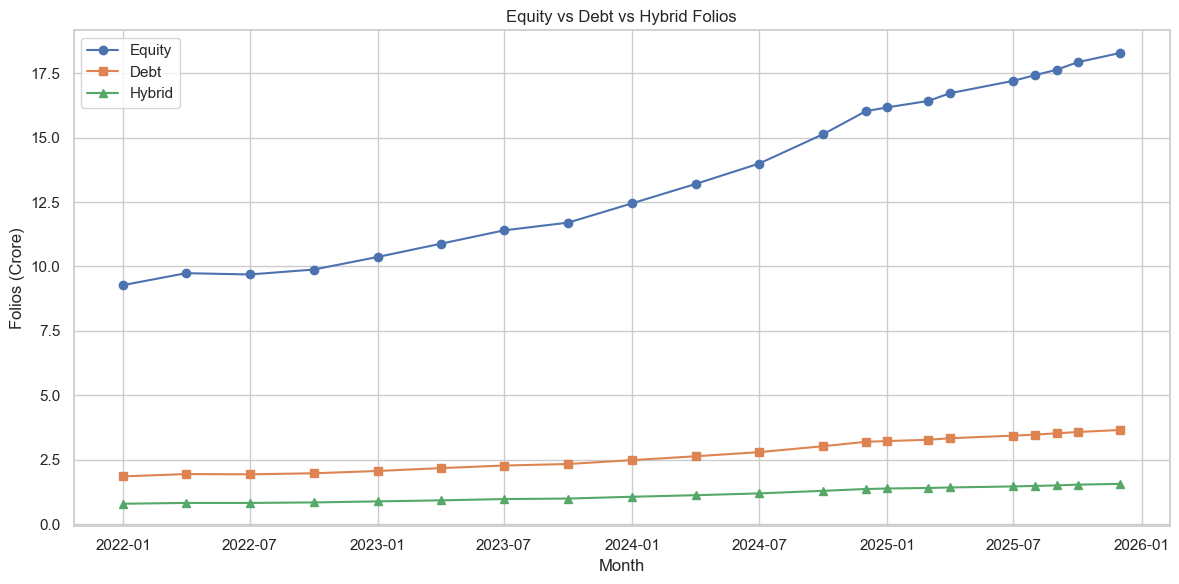

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["equity_folios_crore"],
    marker="o",
    label="Equity"
)

plt.plot(
    folio["month"],
    folio["debt_folios_crore"],
    marker="s",
    label="Debt"
)

plt.plot(
    folio["month"],
    folio["hybrid_folios_crore"],
    marker="^",
    label="Hybrid"
)

plt.title("Equity vs Debt vs Hybrid Folios")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Insight 7

Equity mutual funds consistently maintained the highest number of investor folios, significantly outperforming Debt and Hybrid funds throughout the analysis period, reflecting strong investor preference for equity investments.

In [37]:
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [38]:
top10 = performance.sort_values(
    "return_5yr_pct",
    ascending=False
).head(10)

top10[["scheme_name", "return_5yr_pct"]]

,scheme_name,return_5yr_pct
29,ABSL Small Cap Fund - Regular - Growth,23.80
27,Axis Small Cap Fund - Regular - Growth,22.62
17,Nippon India Small Cap Fund - Regular - Growth,21.88
3,SBI Small Cap Fund - Direct Plan - Growth,21.82
2,SBI Small Cap Fund - Regular Plan - Growth,20.67
39,DSP Small Cap Fund - Regular - Growth,20.61
38,DSP Midcap Fund - Regular - Growth,19.00
26,Axis Midcap Fund - Regular - Growth,18.94
21,Kotak Emerging Equity Fund - Regular - Growth,17.75
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,17.69


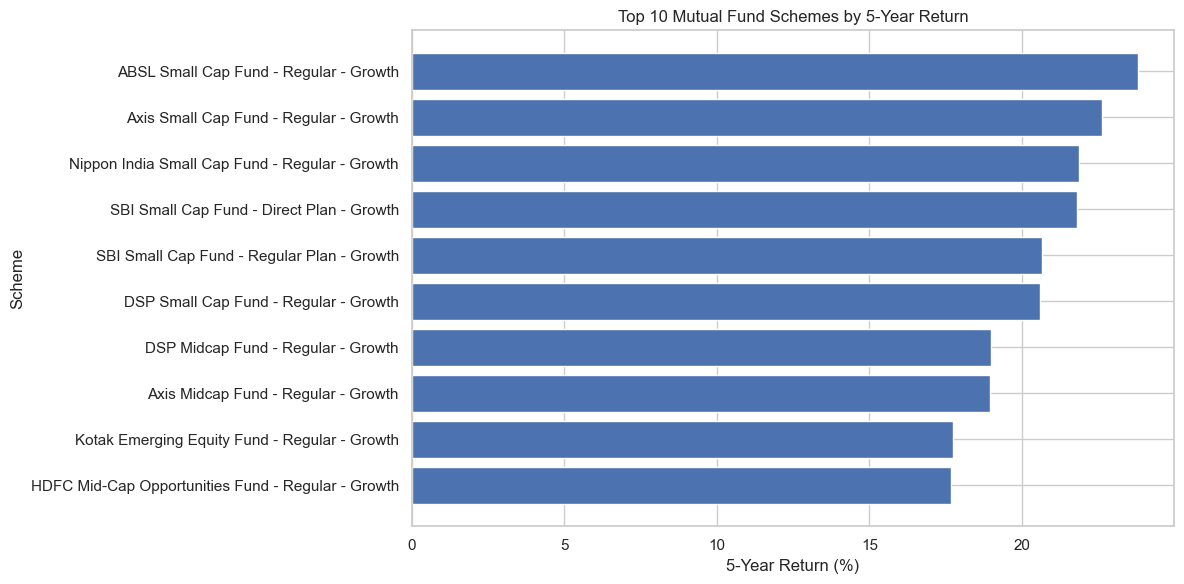

In [39]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top10["scheme_name"],
    top10["return_5yr_pct"]
)

plt.title("Top 10 Mutual Fund Schemes by 5-Year Return")
plt.xlabel("5-Year Return (%)")
plt.ylabel("Scheme")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Insight 8

The top-performing mutual fund schemes delivered significantly higher 5-year returns, indicating strong long-term wealth creation potential for investors.

In [40]:
performance.groupby("risk_grade")["return_5yr_pct"].mean().sort_values(ascending=False)

risk_grade
Very High          21.900000
High               17.112500
Moderately High    14.390000
Moderate           13.131875
Low                 7.450000
Name: return_5yr_pct, dtype: float64

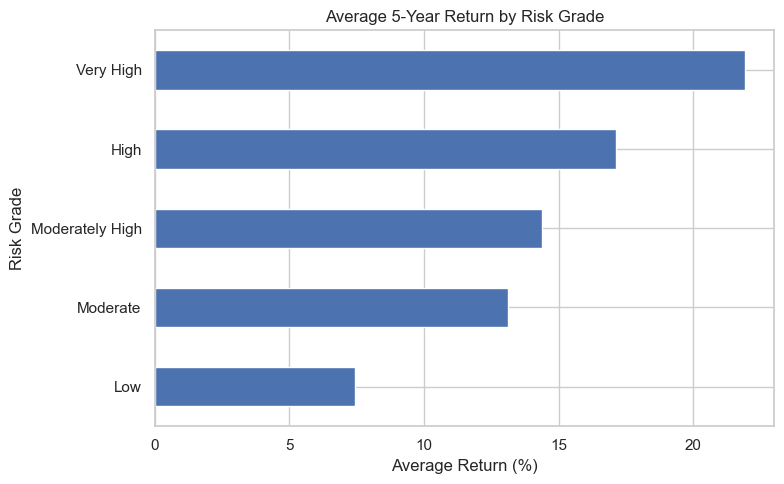

In [41]:
risk_return = performance.groupby("risk_grade")["return_5yr_pct"].mean().sort_values()

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
risk_return.plot(kind="barh")
plt.title("Average 5-Year Return by Risk Grade")
plt.xlabel("Average Return (%)")
plt.ylabel("Risk Grade")
plt.tight_layout()
plt.show()

## Insight 9

Higher risk-grade mutual funds generally delivered better average 5-year returns, highlighting the classic risk-return tradeoff where investors taking greater risk were rewarded with higher long-term performance.

In [42]:
top_sharpe = performance.sort_values(
    "sharpe_ratio",
    ascending=False
).head(10)

top_sharpe[["scheme_name", "sharpe_ratio"]]

,scheme_name,sharpe_ratio
14,ICICI Pru Liquid Fund - Regular - Growth,7.68
23,Kotak Liquid Fund - Regular - Growth,6.18
30,ABSL Liquid Fund - Regular - Growth,5.14
9,HDFC Short Term Debt Fund - Regular - Growth,1.84
4,SBI Magnum Gilt Fund - Regular Plan - Growth,1.52
19,Nippon India Gilt Securities Fund - Regular - ...,1.33
34,Mirae Asset Large Cap Fund - Regular - Growth,1.06
5,HDFC Top 100 Fund - Regular Plan - Growth,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,1.03
15,Nippon India Large Cap Fund - Regular - Growth,1.00


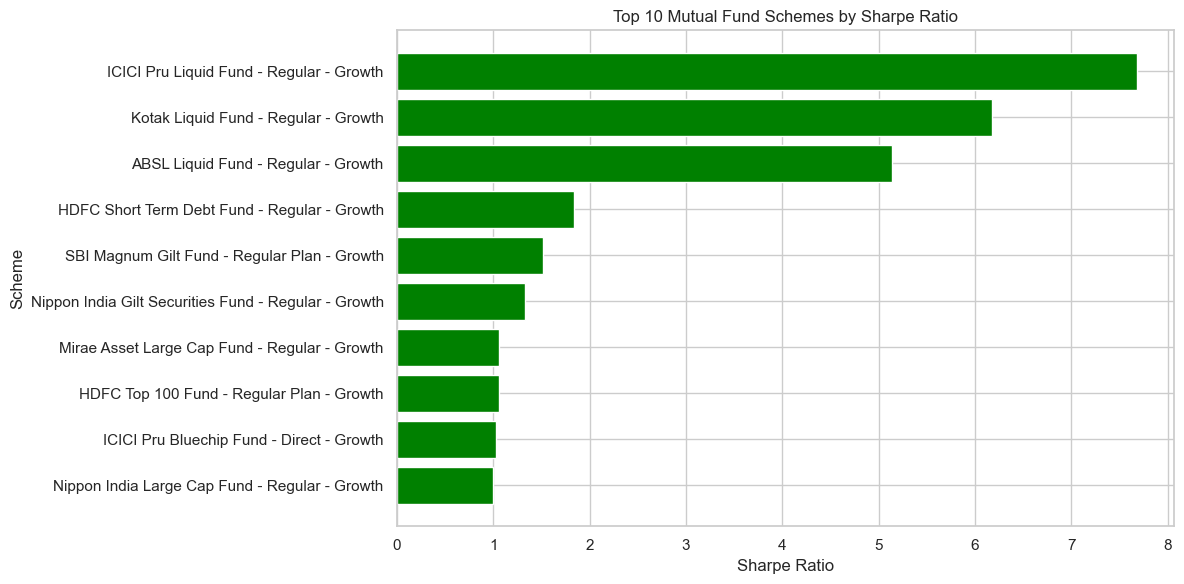

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.barh(
    top_sharpe["scheme_name"],
    top_sharpe["sharpe_ratio"],
    color="green"
)

plt.title("Top 10 Mutual Fund Schemes by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Insight 10

Mutual fund schemes with higher Sharpe Ratios delivered better risk-adjusted returns, indicating that these schemes generated superior returns for every unit of risk taken, making them attractive long-term investment options.

In [ ]:
df.groupby("risk_category")["expense_ratio_pct"].mean()

risk_category
High               1.397500
Low                0.668333
Moderate           1.260000
Moderately High    1.505000
Very High          1.351667
Name: expense_ratio_pct, dtype: float64

In [ ]:
df.groupby("fund_house")["expense_ratio_pct"].mean().sort_values(ascending=False)

fund_house
UTI Mutual Fund             1.573333
DSP Mutual Fund             1.556667
Mirae Asset MF              1.526667
Aditya Birla Sun Life MF    1.306667
Kotak Mahindra MF           1.300000
Axis Mutual Fund            1.287500
ICICI Prudential MF         1.146000
Nippon India MF             1.040000
HDFC Mutual Fund            1.038000
SBI Mutual Fund             1.024000
Name: expense_ratio_pct, dtype: float64

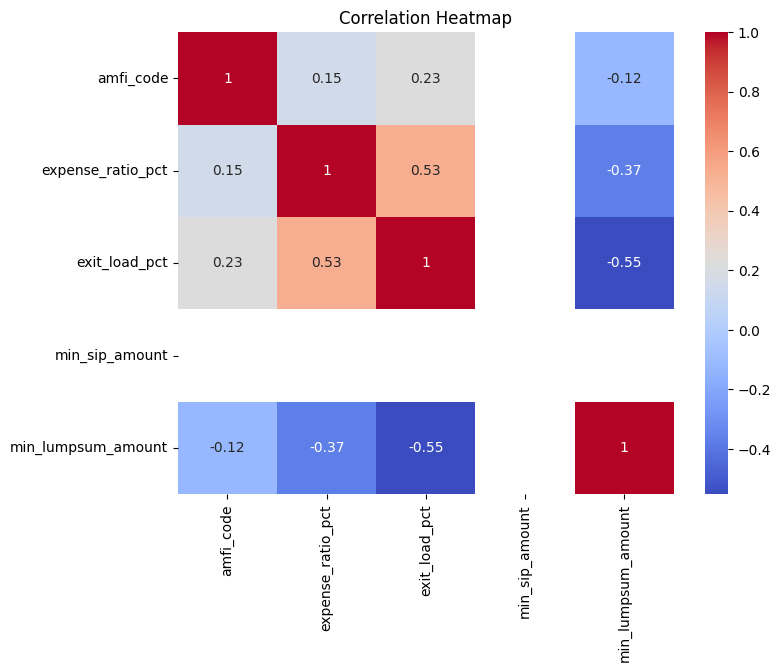

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

# Key Insights

1. Most mutual funds belong to the High Risk category.
2. Low Risk funds have the lowest average expense ratio.
3. UTI Mutual Fund has the highest average expense ratio in this sample.
4. The dataset contains 40 records and 15 columns with no missing values.
5. Numerical features are clean and suitable for further analysis.

# Conclusion

This project successfully analyzed mutual fund data using Python, Pandas, SQLite, Matplotlib, and Seaborn.

The analysis explored risk categories, expense ratios, fund houses, and category distributions through visualizations. The dataset was clean, consistent, and free from missing values, making it suitable for investment-related exploratory analysis.

This dashboard can help investors compare mutual funds and understand their characteristics before making investment decisions.

In [ ]:
import matplotlib
print(matplotlib.__version__)

3.10.8


In [ ]:
import os

print(os.getcwd())
print(os.listdir())

c:\Users\ASUS\Desktop\capstone-mutual-fund-analytics\notebooks
['.ipynb_checkpoints', 'eda_analysis.ipynb', 'mutual_fund.db', 'Untitled.ipynb']
